# Notebook 05 — CARMA Kalman Filter (Python validation)

Runs discrete-observation Kalman filters for CARMA$(2,1)$ temperature and CARMA$(3,2)$ log-price using the QMLE parameter files exported by notebooks 06/07. The state-space form is

$$dZ_t = A\,Z_t\,dt + \sigma e_p\,dW_t, \qquad Y_k = b^\top Z_{t_k} + \varepsilon_k.$$

The continuous-time transition and process covariance are discretized exactly. For the stable fitted CARMA matrices, the covariance is computed from the stationary Lyapunov equation to avoid numerical cancellation over long gaps. Fit quality is assessed through one-step predictions, log-likelihood, AIC, and Ljung-Box tests on standardized innovations.

**Inputs:** `data/deseasonalised/temp_resid.csv`, `data/deseasonalised/price_resid.csv`, `data/kalman/temp_carma_params.csv`, `data/kalman/price_carma_params.csv`  
**Saved arrays:** `data/kalman/y_hat_price.npy`, `data/kalman/x_hat_price.npy`


### CARMA(2,1) — temperature

Parameters are loaded directly from `data/kalman/temp_carma_params.csv`, exported by notebook 06. The filter uses the same hourly scale as the fitted parameters, with $h = 1$ hour.

The companion-state observation equation is

$$Y_k = b_0 Z_{1,k} + b_1 Z_{2,k}.$$


In [1]:
import numpy as np
import pandas as pd
from scipy.linalg import expm, solve_continuous_lyapunov


def load_carma_params(path):
    df = pd.read_csv(path)
    name_col = "name" if "name" in df.columns else df.columns[0]
    value_col = "value" if "value" in df.columns else df.columns[1]
    return dict(zip(df[name_col].astype(str), df[value_col].astype(float)))


def hours_from_index(index):
    index = pd.DatetimeIndex(pd.to_datetime(index, utc=True))
    return ((index - index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)


def add_abs_ratio(df, numerator="OOS 2026", denominator="train", eps=1e-4):
    denom = df[denominator].abs()
    ratio = np.where(denom > eps, df[numerator].abs() / denom, np.nan)
    mean_rows = df.index.to_series().str.contains("mean", case=False, regex=False)
    ratio = np.where(mean_rows, np.nan, ratio)
    df["ratio (OOS/train)"] = ratio
    return df


temp_resid = pd.read_csv("../data/deseasonalised/temp_resid.csv", index_col=0)
temp_res = temp_resid["temp_deseasoned"].copy()
time_temp = pd.to_datetime(temp_res.index, utc=True)

y = temp_res.to_numpy(dtype=float)
t = hours_from_index(time_temp)

params_temp = load_carma_params("../data/kalman/temp_carma_params.csv")
a1 = params_temp["a1"]
a2 = params_temp["a2"]
b0 = params_temp["b0"]
b1 = params_temp["b1"]
sigma = params_temp["sig"]

yerr = np.full_like(y, 1e-6, dtype=float)


def project_symmetric_psd(M, floor=1e-15):
    M = 0.5 * (M + M.T)
    eigvals, eigvecs = np.linalg.eigh(M)
    if eigvals.min() < floor:
        eigvals = np.maximum(eigvals, floor)
        M = (eigvecs * eigvals) @ eigvecs.T
        M = 0.5 * (M + M.T)
    return M


def discretize_linear_sde(A, G, dt):
    # Exact discrete transition and covariance for dX = A X dt + G dW.
    dt = float(dt)
    if dt < 0:
        raise ValueError("Time step must be non-negative")

    n = A.shape[0]
    F = expm(A * dt)
    Qc = G @ G.T

    # The fitted CARMA matrices are stationary. In that case the Lyapunov form
    # avoids the numerical cancellation that Van Loan can suffer over long gaps.
    if np.max(np.real(np.linalg.eigvals(A))) < 0:
        P_inf = solve_continuous_lyapunov(A, -Qc)
        Q = P_inf - F @ P_inf @ F.T
    else:
        M = np.block([
            [A, Qc],
            [np.zeros((n, n)), -A.T],
        ]) * dt
        E = expm(M)
        Q = E[:n, n:] @ F.T

    return F, project_symmetric_psd(Q)


def kalman_filter_carma21(t, y, a1, a2, b0, b1, sigma, yerr=None,
                          x0=None, P0=None, jitter=1e-10):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.full_like(y, 1e-6) if yerr is None else np.asarray(yerr, dtype=float)

    if not np.all(np.diff(t) > 0):
        raise ValueError("Time index must be strictly increasing")

    n, m = len(y), 2

    A = np.array([[0.0, 1.0], [-a2, -a1]], dtype=float)
    L = np.array([[0.0], [sigma]], dtype=float)
    H = np.array([[b0, b1]], dtype=float)

    x_prev = np.zeros(m) if x0 is None else np.asarray(x0, dtype=float)
    P_prev = np.eye(m) * 1000.0 if P0 is None else np.asarray(P0, dtype=float)

    x_pred = np.zeros((n, m))
    P_pred = np.zeros((n, m, m))
    x_filt = np.zeros((n, m))
    P_filt = np.zeros((n, m, m))
    y_pred = np.zeros(n)
    resid = np.zeros(n)
    std_resid = np.zeros(n)
    S_all = np.zeros(n)
    loglik = 0.0

    I = np.eye(m)

    for k in range(n):
        if k == 0:
            xk_pred, Pk_pred = x_prev, P_prev
        else:
            F, Q = discretize_linear_sde(A, L, t[k] - t[k - 1])
            xk_pred = F @ x_prev
            Pk_pred = F @ P_prev @ F.T + Q
            Pk_pred = project_symmetric_psd(Pk_pred)

        Rk = float(yerr[k] ** 2 + jitter)
        mu = float((H @ xk_pred).item())
        S = float((H @ Pk_pred @ H.T).item() + Rk)
        v = y[k] - mu
        K = (Pk_pred @ H.T) / S

        x_prev = xk_pred + K[:, 0] * v
        KH = K @ H
        P_prev = (I - KH) @ Pk_pred @ (I - KH).T + Rk * (K @ K.T)
        P_prev = project_symmetric_psd(P_prev)

        x_pred[k], P_pred[k] = xk_pred, Pk_pred
        x_filt[k], P_filt[k] = x_prev, P_prev
        y_pred[k] = mu
        resid[k] = v
        std_resid[k] = v / np.sqrt(S)
        S_all[k] = S
        loglik += -0.5 * (np.log(2 * np.pi) + np.log(S) + v ** 2 / S)

    return dict(A=A, L=L, H=H,
                x_pred=x_pred, P_pred=P_pred,
                x_filt=x_filt, P_filt=P_filt,
                y_pred=y_pred, resid=resid,
                std_resid=std_resid, S=S_all, loglik=float(loglik))


res = kalman_filter_carma21(
    t=t, y=y, a1=a1, a2=a2, b0=b0, b1=b1, sigma=sigma, yerr=yerr
)

y_hat = res["y_pred"]
innov = res["resid"]
z = res["std_resid"]
loglik = res["loglik"]
x_hat = res["x_pred"]
y_hat_temp = y_hat.copy()
x_hat_temp = x_hat.copy()

n_params_temp = 5
aic = -2 * loglik + 2 * n_params_temp
rmse = np.sqrt(np.mean((y - y_hat) ** 2))
mae = np.mean(np.abs(y - y_hat))

print("=== CARMA(2,1) — TEMPERATURE ===")
print(f"  a1={a1:.6f}, a2={a2:.6f}, b0={b0:.6f}, b1={b1:.6f}, sigma={sigma:.6f}")
print(f"  Log-likelihood: {loglik:.4f}")
print(f"  AIC:            {aic:.2f}")
print(f"  RMSE:           {rmse:.6f}")
print(f"  MAE:            {mae:.6f}")
print(f"  Eigenvalues of A: {np.linalg.eigvals(res['A'])}")

res_temp = res


=== CARMA(2,1) — TEMPERATURE ===
  a1=0.834603, a2=0.024736, b0=1.000000, b1=0.584421, sigma=0.769633
  Log-likelihood: -48521.0045
  AIC:            97052.01
  RMSE:           0.608516
  MAE:            0.418532
  Eigenvalues of A: [-0.03077297 -0.80382959]


#### Kalman filter diagnostics — temperature CARMA(2,1)

Evaluates filter performance via standardized one-step-ahead prediction errors (innovations) $\tilde{v}_k = v_k / \sqrt{F_k}$. Under correct model specification, innovations should be i.i.d. $\mathcal{N}(0,1)$. A Ljung–Box test on $\{\tilde{v}_k\}$ checks for residual autocorrelation; a histogram and QQ-plot assess Gaussianity.

        lb_stat  lb_pvalue
24  2436.862608        0.0
48  4101.911628        0.0
72  5260.403004        0.0


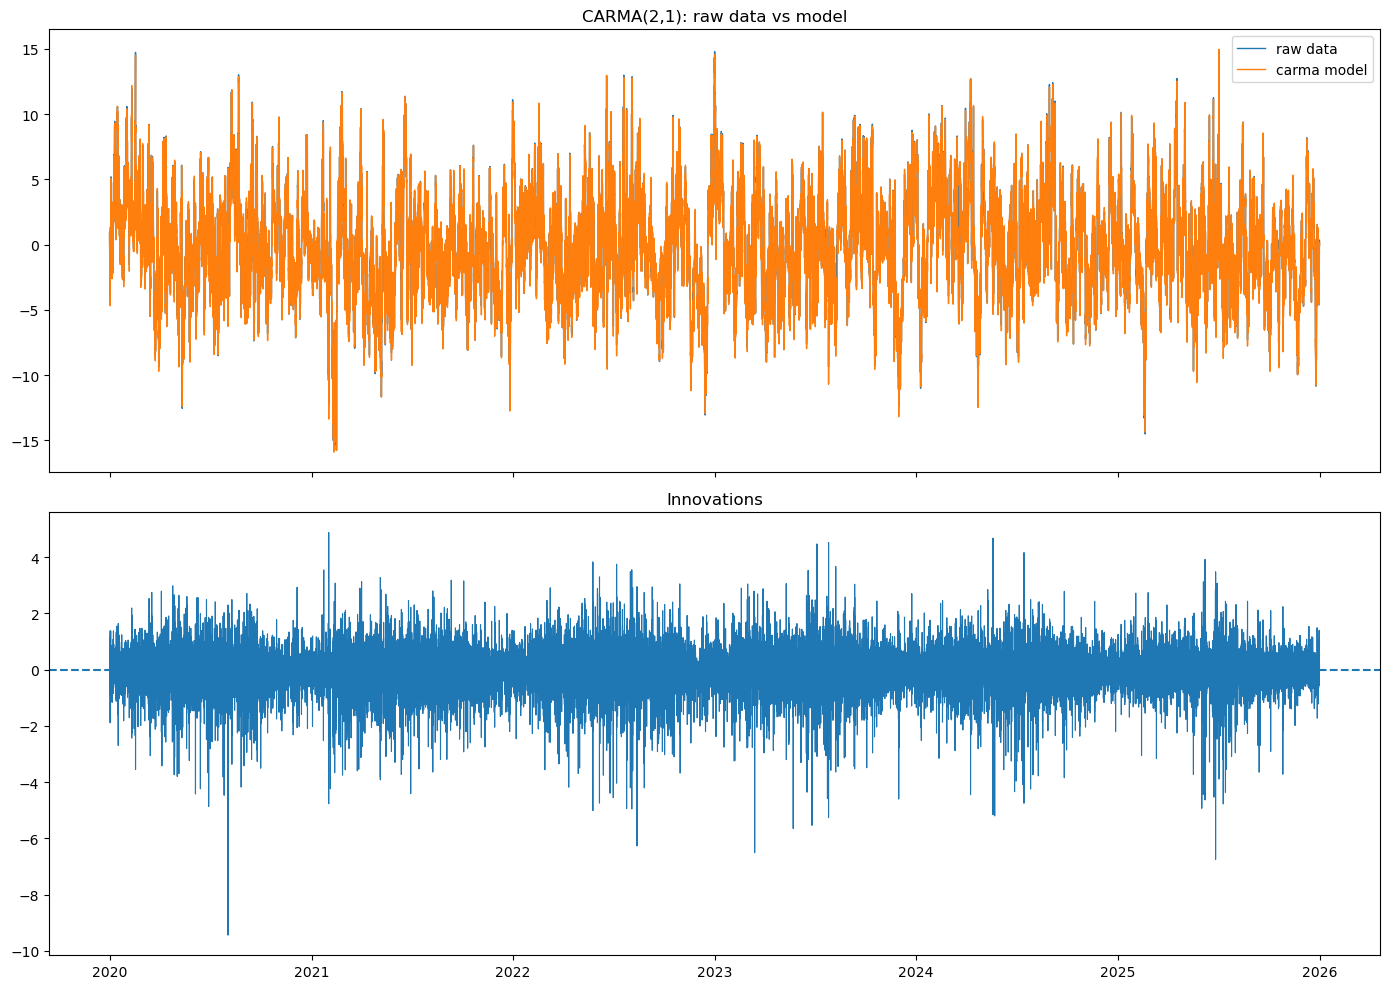

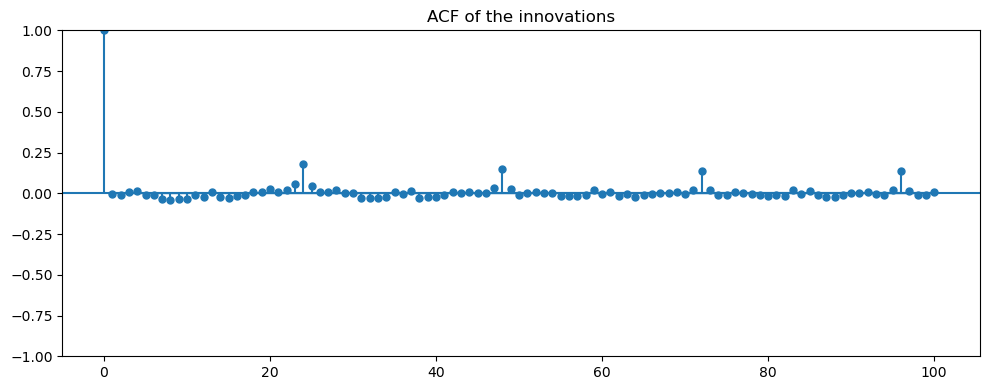

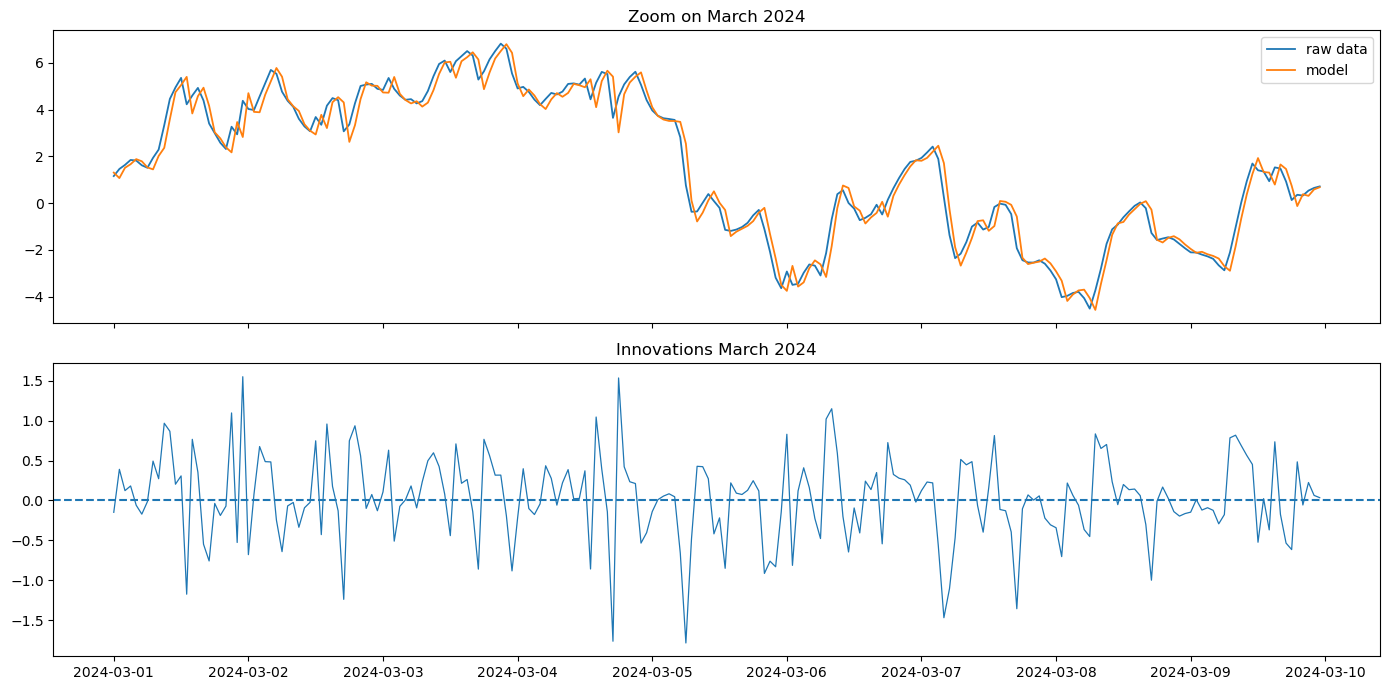

In [2]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(z, lags=[24, 48, 72], return_df=True)
print(lb)

fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax[0].plot(time_temp, y, label="raw data", linewidth=1)
ax[0].plot(time_temp, y_hat, label="carma model", linewidth=1)
ax[0].legend()
ax[0].set_title("CARMA(2,1): raw data vs model")

ax[1].plot(time_temp, innov, linewidth=0.8)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Innovations")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(z, lags=100, ax=ax)
ax.set_title("ACF of the innovations")
plt.tight_layout()
plt.show()

mask_march = (
    (time_temp >= pd.Timestamp("2024-03-01", tz="UTC")) &
    (time_temp <  pd.Timestamp("2024-03-10", tz="UTC"))
)
time_march = time_temp[mask_march]
y_march = y[mask_march]
yhat_march = y_hat[mask_march]
innov_march = innov[mask_march]

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(time_march, y_march, label="raw data", linewidth=1.3)
ax[0].plot(time_march, yhat_march, label="model", linewidth=1.3)
ax[0].legend()
ax[0].set_title("Zoom on March 2024")

ax[1].plot(time_march, innov_march, linewidth=0.9)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Innovations March 2024")

plt.tight_layout()
plt.show()

### Out-of-sample CARMA(2,1) — temperature (2026)

Applies the CARMA(2,1) parameters estimated on 2020–2025 to deseasonalized temperature residuals for January–April 2026. The Fourier seasonal model is reconstructed from the saved coefficients (notebook 02). The Kalman filter is warm-started from the last filtered state of the training period.

In [3]:
# Load 2026 temperature data (raw, seasonal, residuals) from notebook 02
_df26 = pd.read_csv(
    "../data/deseasonalised/temp_2026_full.csv", index_col=0
)
# utc=True preserves timezone so March mask works correctly
_df26.index = pd.to_datetime(_df26.index, utc=True)

time_2026       = _df26.index
temp_2026_raw   = _df26["temp_raw"].to_numpy(dtype=float)
temp_2026_seas  = _df26["temp_seas"].to_numpy(dtype=float)
temp_2026_resid = _df26["temp_resid"].to_numpy(dtype=float)

print(f"2026 obs: {len(temp_2026_resid)}  "
      f"({str(time_2026[0].date())} to {str(time_2026[-1].date())})")
print(f"Residual std 2026 : {temp_2026_resid.std():.4f}  "
      f"(train: {temp_res.std():.4f})")
print(f"Raw temp  std 2026 : {temp_2026_raw.std():.4f}")
print(f"Ratio resid/raw std: "
      f"{temp_2026_resid.std()/temp_2026_raw.std():.3f}  "
      f"(should be < 1 if deseasonalization works)")


2026 obs: 2688  (2026-01-01 to 2026-04-22)
Residual std 2026 : 4.3452  (train: 3.7931)
Raw temp  std 2026 : 6.3650
Ratio resid/raw std: 0.683  (should be < 1 if deseasonalization works)


=== CARMA(2,1) temperature — in-sample vs OOS diagnostics ===
                      train   OOS 2026  ratio (OOS/train)
Log-lik         -48521.0045 -2078.8781             0.0428
Log-lik / obs       -0.9223    -0.7734             0.8385
AIC              97052.0090  4167.7563             0.0429
RMSE                 0.6085     0.5100             0.8381
MAE                  0.4185     0.3765             0.8997
Innovation mean      0.0000    -0.0266                NaN
Innovation std       0.6085     0.5093             0.8369
Std innov mean       0.0000    -0.0437                NaN
Std innov std        1.0000     0.8370             0.8370


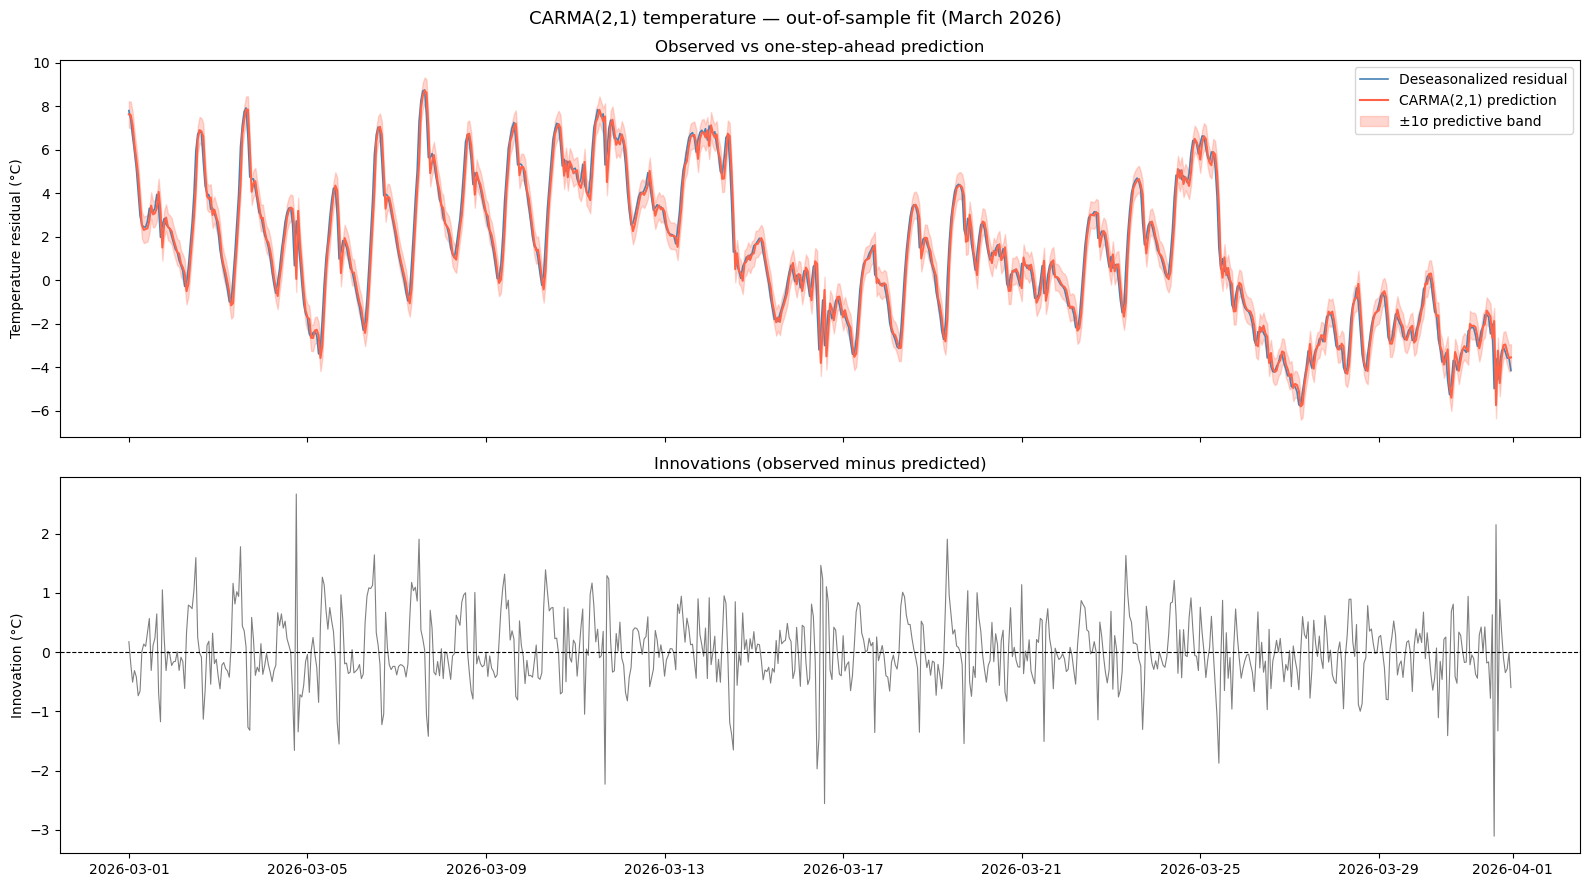

In [4]:
# Warm-start from the last training state to the first 2026 observation.
_A_tr = res_temp["A"]
_L_tr = res_temp["L"]
dt_gap = float((time_2026[0] - time_temp[-1]) / pd.Timedelta(hours=1))
_F_gap, _Q_gap = discretize_linear_sde(_A_tr, _L_tr, dt=dt_gap)
x0_oos = _F_gap @ res_temp["x_filt"][-1]
P0_oos = _F_gap @ res_temp["P_filt"][-1] @ _F_gap.T + _Q_gap
P0_oos = project_symmetric_psd(P0_oos)

y_2026 = temp_2026_resid.astype(float)
t_2026 = hours_from_index(time_2026)
err_2026 = np.full(len(y_2026), 1e-6)

res_2026 = kalman_filter_carma21(
    t=t_2026, y=y_2026,
    a1=a1, a2=a2, b0=b0, b1=b1, sigma=sigma,
    yerr=err_2026, x0=x0_oos, P0=P0_oos,
)
y_hat_2026 = res_2026["y_pred"]
innov_2026 = res_2026["resid"]
z_2026 = res_2026["std_resid"]

n_params = 5
loglik_train = float(res_temp["loglik"])
loglik_oos = float(res_2026["loglik"])
n_train = len(y)
n_oos = len(y_2026)

metrics = {
    "Log-lik": {
        "train": loglik_train,
        "OOS 2026": loglik_oos,
    },
    "Log-lik / obs": {
        "train": loglik_train / n_train,
        "OOS 2026": loglik_oos / n_oos,
    },
    "AIC": {
        "train": -2 * loglik_train + 2 * n_params,
        "OOS 2026": -2 * loglik_oos + 2 * n_params,
    },
    "RMSE": {
        "train": float(np.sqrt(np.mean((y - y_hat) ** 2))),
        "OOS 2026": float(np.sqrt(np.mean((y_2026 - y_hat_2026) ** 2))),
    },
    "MAE": {
        "train": float(np.mean(np.abs(y - y_hat))),
        "OOS 2026": float(np.mean(np.abs(y_2026 - y_hat_2026))),
    },
    "Innovation mean": {
        "train": float(res_temp["resid"].mean()),
        "OOS 2026": float(innov_2026.mean()),
    },
    "Innovation std": {
        "train": float(res_temp["resid"].std()),
        "OOS 2026": float(innov_2026.std()),
    },
    "Std innov mean": {
        "train": float(res_temp["std_resid"].mean()),
        "OOS 2026": float(z_2026.mean()),
    },
    "Std innov std": {
        "train": float(res_temp["std_resid"].std()),
        "OOS 2026": float(z_2026.std()),
    },
}

diag = pd.DataFrame(metrics).T
diag = add_abs_ratio(diag)
print("=== CARMA(2,1) temperature — in-sample vs OOS diagnostics ===")
print(diag.round(4).to_string())

mask_mar26 = (time_2026 >= pd.Timestamp("2026-03-01", tz="UTC")) & (
    time_2026 < pd.Timestamp("2026-04-01", tz="UTC")
)

t_mar = time_2026[mask_mar26]
y_mar = y_2026[mask_mar26]
yhat_mar = y_hat_2026[mask_mar26]
inn_mar = innov_2026[mask_mar26]
_S_mar = res_2026["S"][mask_mar26]
_std_mar = np.sqrt(_S_mar)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle("CARMA(2,1) temperature — out-of-sample fit (March 2026)", fontsize=13)

axes[0].plot(t_mar, y_mar, linewidth=1.2, label="Deseasonalized residual", color="steelblue")
axes[0].plot(t_mar, yhat_mar, linewidth=1.5, label="CARMA(2,1) prediction", color="tomato")
axes[0].fill_between(
    t_mar, yhat_mar - _std_mar, yhat_mar + _std_mar,
    alpha=0.25, color="tomato", label="±1σ predictive band",
)
axes[0].legend()
axes[0].set_ylabel("Temperature residual (°C)")
axes[0].set_title("Observed vs one-step-ahead prediction")

axes[1].plot(t_mar, inn_mar, linewidth=0.8, color="grey")
axes[1].axhline(0, linestyle="--", color="k", linewidth=0.8)
axes[1].set_ylabel("Innovation (°C)")
axes[1].set_title("Innovations (observed minus predicted)")

plt.tight_layout()
plt.show()


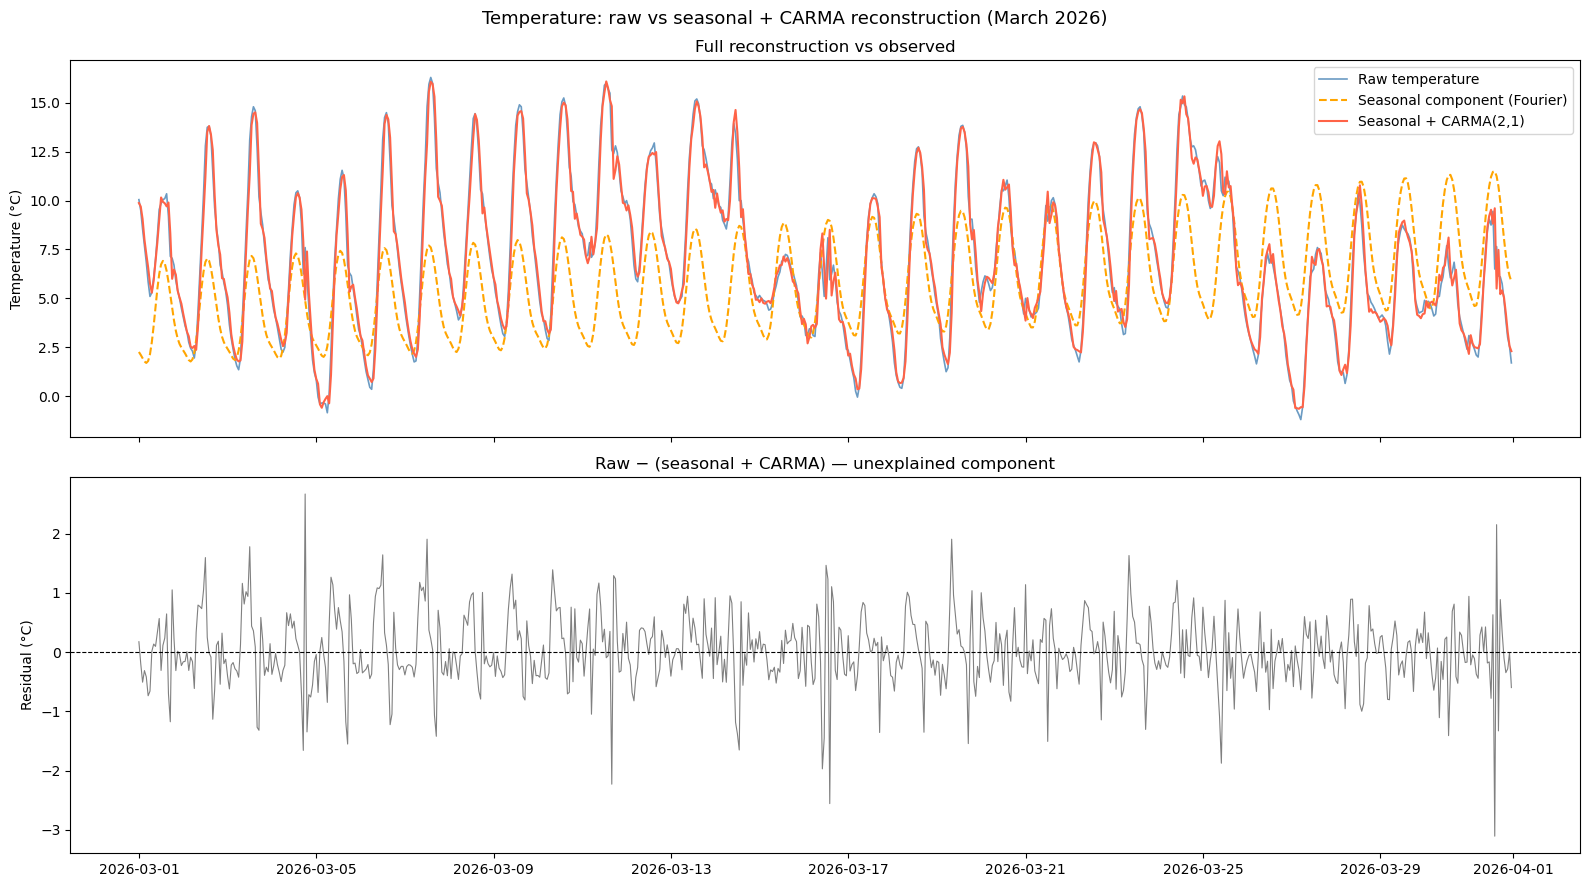

RMSE seasonal only    : 3.4518 °C
RMSE seasonal + CARMA : 0.5980 °C
CARMA improvement     : 82.7%


In [5]:
# Reconstruction: raw temperature vs seasonal + CARMA fit (March 2026)
mask_mar = (time_2026 >= pd.Timestamp("2026-03-01", tz="UTC")) & \
           (time_2026 <  pd.Timestamp("2026-04-01", tz="UTC"))

t_mar       = time_2026[mask_mar]
raw_mar     = temp_2026_raw[mask_mar]
seas_mar    = temp_2026_seas[mask_mar]
carma_mar   = y_hat_2026[mask_mar]         # CARMA one-step-ahead on residuals
recon_mar   = seas_mar + carma_mar         # full reconstruction

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle("Temperature: raw vs seasonal + CARMA reconstruction (March 2026)",
             fontsize=13)

axes[0].plot(t_mar, raw_mar,   linewidth=1.2, alpha=0.8,
             label="Raw temperature",              color="steelblue")
axes[0].plot(t_mar, seas_mar,  linewidth=1.5, linestyle="--",
             label="Seasonal component (Fourier)",  color="orange")
axes[0].plot(t_mar, recon_mar, linewidth=1.5,
             label="Seasonal + CARMA(2,1)",         color="tomato")
axes[0].set_ylabel("Temperature (\u00b0C)")
axes[0].set_title("Full reconstruction vs observed")
axes[0].legend()

axes[1].plot(t_mar, raw_mar - recon_mar, linewidth=0.8, color="grey")
axes[1].axhline(0, linestyle="--", color="k", linewidth=0.8)
axes[1].set_ylabel("Residual (\u00b0C)")
axes[1].set_title("Raw − (seasonal + CARMA) — unexplained component")

plt.tight_layout()
plt.show()

rmse_recon = float(np.sqrt(np.mean((raw_mar - recon_mar) ** 2)))
rmse_seas  = float(np.sqrt(np.mean((raw_mar - seas_mar)  ** 2)))
print(f"RMSE seasonal only    : {rmse_seas:.4f} \u00b0C")
print(f"RMSE seasonal + CARMA : {rmse_recon:.4f} \u00b0C")
print(f"CARMA improvement     : {(1 - rmse_recon/rmse_seas)*100:.1f}%")


### CARMA(3,2) — log-price

Parameters are loaded directly from `data/kalman/price_carma_params.csv`, exported by notebook 07. The filter uses the same hourly scale as the fitted parameters, with $h = 1$ hour.

The companion-state observation equation is

$$Y_k = b_0 Z_{1,k} + b_1 Z_{2,k} + b_2 Z_{3,k}.$$


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)
price_res = price_resid["price_deseasoned"].copy()
time_price = pd.to_datetime(price_res.index, utc=True)

y = price_res.to_numpy(dtype=float)
t = hours_from_index(time_price)

params_price = load_carma_params("../data/kalman/price_carma_params.csv")
a1 = params_price["a1"]
a2 = params_price["a2"]
a3 = params_price["a3"]
b0 = params_price["b0"]
b1 = params_price["b1"]
b2 = params_price["b2"]
sigma = params_price["sig"]

yerr = np.full_like(y, 1e-6, dtype=float)


def kalman_filter_carma32(t, y, a1, a2, a3, b0, b1, b2, sigma,
                          yerr=None, x0=None, P0=None, jitter=1e-10):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.full_like(y, 1e-6) if yerr is None else np.asarray(yerr, dtype=float)

    if not np.all(np.diff(t) > 0):
        raise ValueError("Time index must be strictly increasing")

    n, m = len(y), 3

    A = np.array([[0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0],
                  [-a3, -a2, -a1]], dtype=float)
    L = np.array([[0.0], [0.0], [sigma]], dtype=float)
    H = np.array([[b0, b1, b2]], dtype=float)

    x_prev = np.zeros(m) if x0 is None else np.asarray(x0, dtype=float)
    P_prev = np.eye(m) * 1000.0 if P0 is None else np.asarray(P0, dtype=float)

    x_pred = np.zeros((n, m))
    P_pred = np.zeros((n, m, m))
    x_filt = np.zeros((n, m))
    P_filt = np.zeros((n, m, m))
    y_pred = np.zeros(n)
    resid = np.zeros(n)
    std_resid = np.zeros(n)
    S_all = np.zeros(n)
    loglik = 0.0

    I = np.eye(m)

    for k in range(n):
        if k == 0:
            xk_pred, Pk_pred = x_prev, P_prev
        else:
            F, Q = discretize_linear_sde(A, L, t[k] - t[k - 1])
            xk_pred = F @ x_prev
            Pk_pred = F @ P_prev @ F.T + Q
            Pk_pred = project_symmetric_psd(Pk_pred)

        Rk = float(yerr[k] ** 2 + jitter)
        mu = float((H @ xk_pred).item())
        S = float((H @ Pk_pred @ H.T).item() + Rk)
        v = y[k] - mu
        K = (Pk_pred @ H.T) / S

        x_prev = xk_pred + K[:, 0] * v
        KH = K @ H
        P_prev = (I - KH) @ Pk_pred @ (I - KH).T + Rk * (K @ K.T)
        P_prev = project_symmetric_psd(P_prev)

        x_pred[k], P_pred[k] = xk_pred, Pk_pred
        x_filt[k], P_filt[k] = x_prev, P_prev
        y_pred[k] = mu
        resid[k] = v
        std_resid[k] = v / np.sqrt(S)
        S_all[k] = S
        loglik += -0.5 * (np.log(2 * np.pi) + np.log(S) + v ** 2 / S)

    return dict(A=A, L=L, H=H,
                x_pred=x_pred, P_pred=P_pred,
                x_filt=x_filt, P_filt=P_filt,
                y_pred=y_pred, resid=resid,
                std_resid=std_resid, S=S_all, loglik=float(loglik))


res = kalman_filter_carma32(
    t=t, y=y, a1=a1, a2=a2, a3=a3,
    b0=b0, b1=b1, b2=b2, sigma=sigma, yerr=yerr
)

y_hat = res["y_pred"]
innov = res["resid"]
z = res["std_resid"]
loglik = res["loglik"]
x_hat = res["x_pred"]
y_hat_price = y_hat.copy()
x_hat_price = x_hat.copy()

n_params_price = 7
aic = -2 * loglik + 2 * n_params_price
rmse = np.sqrt(np.mean((y - y_hat) ** 2))
mae = np.mean(np.abs(y - y_hat))

print("=== CARMA(3,2) — LOG-PRICE (h = 1 hr) ===")
print(
    f"  a1={a1:.6f}, a2={a2:.6f}, a3={a3:.6f}, "
    f"b0={b0:.6f}, b1={b1:.6f}, b2={b2:.6f}, sigma={sigma:.6f}"
)
print(f"  Log-likelihood: {loglik:.4f}")
print(f"  AIC:            {aic:.2f}")
print(f"  RMSE:           {rmse:.6f}")
print(f"  MAE:            {mae:.6f}")
print(f"  Eigenvalues of A: {np.linalg.eigvals(res['A'])}")

lb = acorr_ljungbox(z, lags=[24, 48, 72], return_df=True)
print("\n=== LJUNG-BOX TEST (standardized innovations) ===")
print(lb)

np.save("../data/kalman/y_hat_price.npy", y_hat_price)
np.save("../data/kalman/x_hat_price.npy", x_hat_price)

res_price = res
a1_p, a2_p, a3_p = a1, a2, a3
b0_p, b1_p, b2_p = b0, b1, b2
sigma_p = sigma


=== CARMA(3,2) — LOG-PRICE (h = 1 hr) ===
  a1=2.741737, a2=1.858273, a3=0.161164, b0=1.000000, b1=-1.691075, b2=0.085606, sigma=0.023063
  Log-likelihood: 78266.5732
  AIC:            -156519.15
  RMSE:           0.012304
  MAE:            0.007379
  Eigenvalues of A: [-0.10131188 -1.71033297 -0.930092  ]



=== LJUNG-BOX TEST (standardized innovations) ===
        lb_stat  lb_pvalue
24  1822.040986        0.0
48  2270.685473        0.0
72  2477.756445        0.0


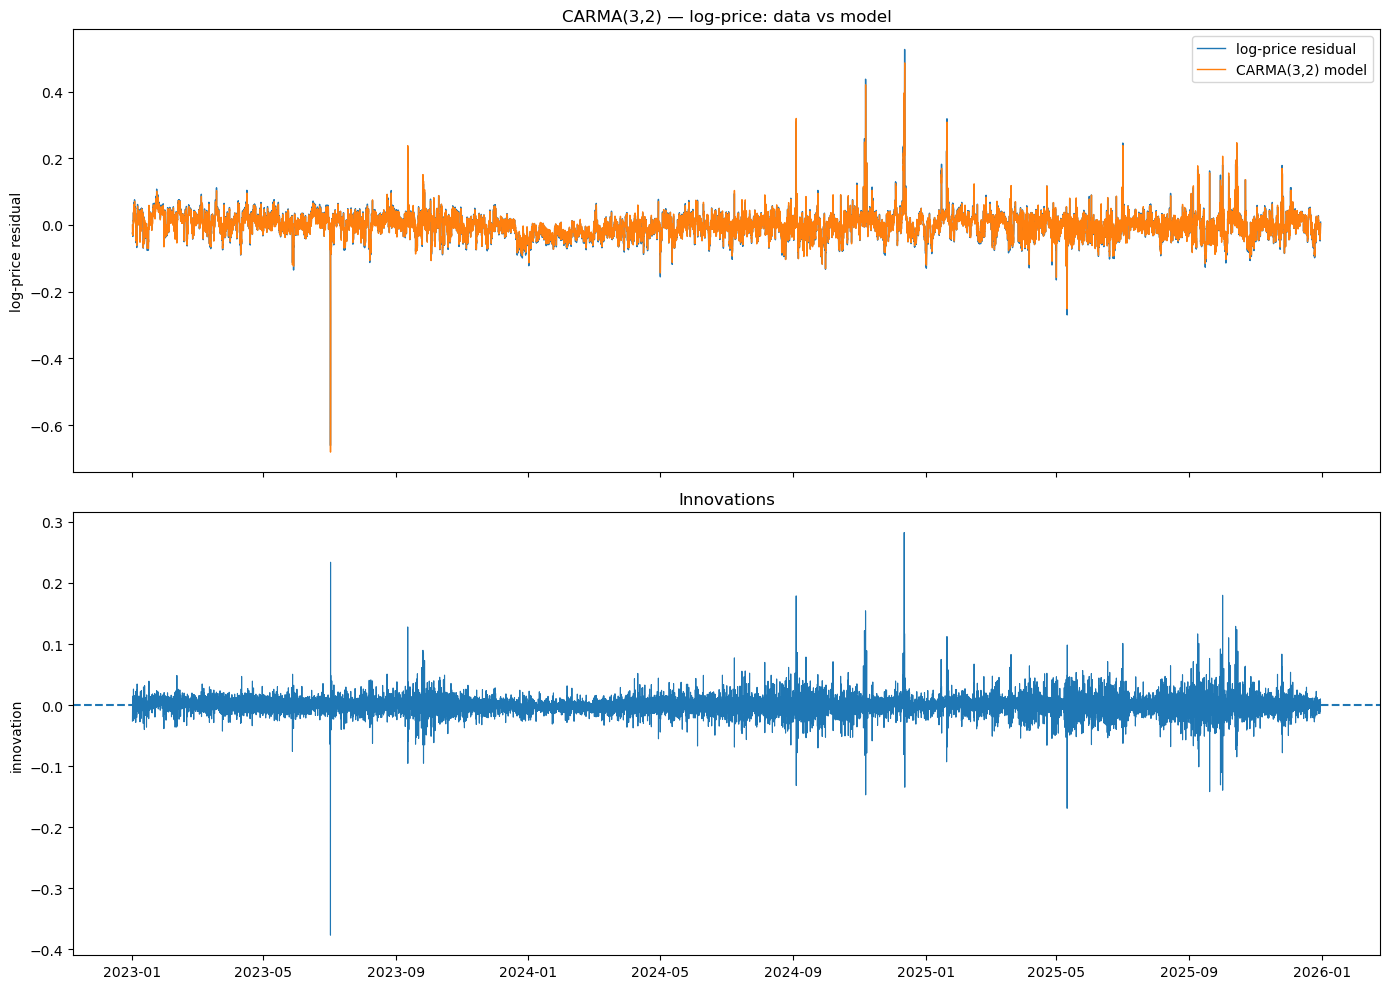

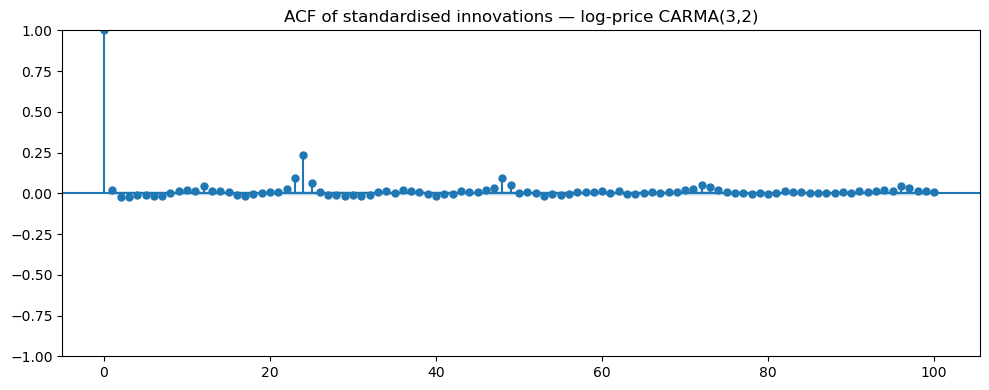

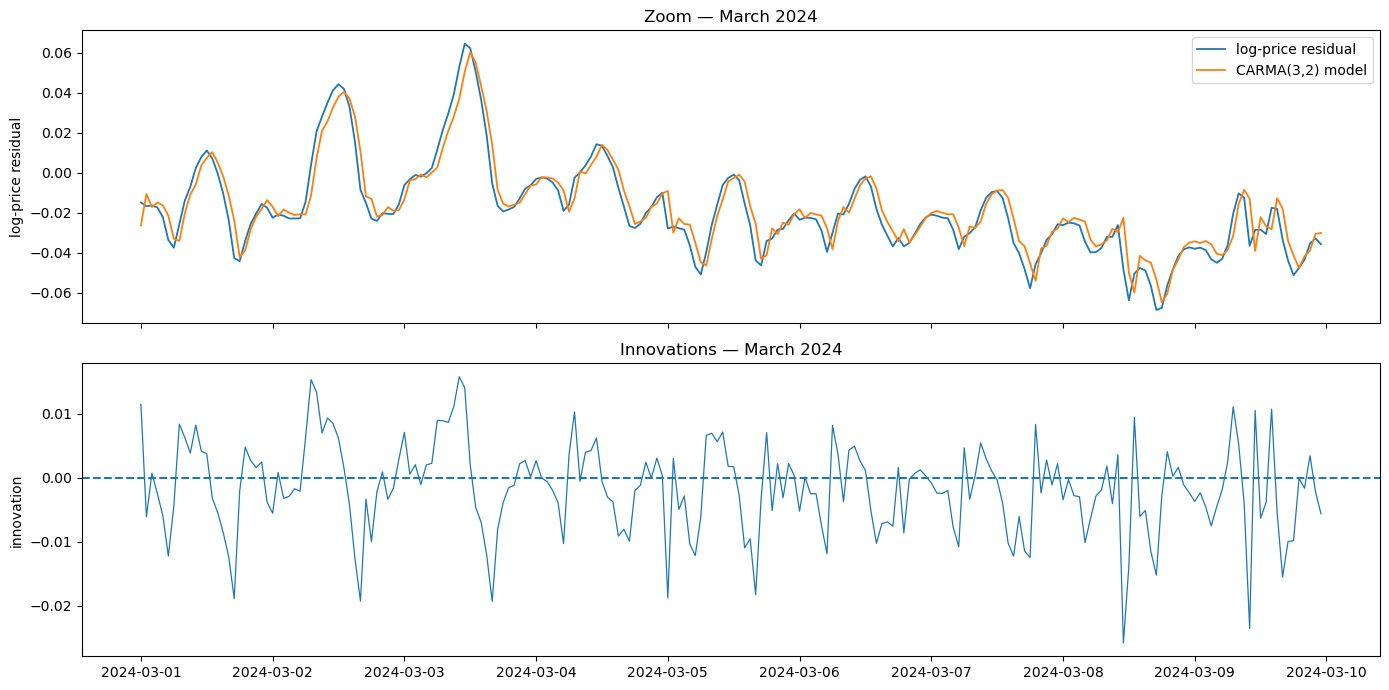

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax[0].plot(time_price, y, label="log-price residual", linewidth=1)
ax[0].plot(time_price, y_hat_price, label="CARMA(3,2) model", linewidth=1)
ax[0].legend()
ax[0].set_title("CARMA(3,2) — log-price: data vs model")
ax[0].set_ylabel("log-price residual")

ax[1].plot(time_price, innov, linewidth=0.8)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Innovations")
ax[1].set_ylabel("innovation")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(z, lags=100, ax=ax)
ax.set_title("ACF of standardised innovations — log-price CARMA(3,2)")
plt.tight_layout()
plt.show()

mask_march = (
    (time_price >= pd.Timestamp("2024-03-01", tz="UTC")) &
    (time_price <  pd.Timestamp("2024-03-10", tz="UTC"))
)
time_march  = time_price[mask_march]
y_march     = y[mask_march]
yhat_march  = y_hat_price[mask_march]
innov_march = innov[mask_march]

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(time_march, y_march,    label="log-price residual", linewidth=1.3)
ax[0].plot(time_march, yhat_march, label="CARMA(3,2) model",   linewidth=1.3)
ax[0].legend()
ax[0].set_title("Zoom — March 2024")
ax[0].set_ylabel("log-price residual")

ax[1].plot(time_march, innov_march, linewidth=0.9)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Innovations — March 2024")
ax[1].set_ylabel("innovation")

plt.tight_layout()
plt.show()

### Out-of-sample CARMA(3,2) — log-price (2026)

Applies the CARMA(3,2) parameters estimated on 2023–2025 to deseasonalized log-price residuals for January–April 2026 (saved by notebook 02). The Kalman filter is warm-started from the last filtered state of the training period.

In [8]:
# Load 2026 log-price data (raw, seasonal, residuals) from notebook 02
_dfp26 = pd.read_csv(
    "../data/deseasonalised/price_2026_full.csv", index_col=0
)
_dfp26.index = pd.to_datetime(_dfp26.index, utc=True)

time_price_26       = _dfp26.index
price_2026_raw      = _dfp26["price_raw"].to_numpy(dtype=float)
price_2026_seas     = _dfp26["price_seas"].to_numpy(dtype=float)
price_2026_resid    = _dfp26["price_resid"].to_numpy(dtype=float)

# NaN check (missing days at boundary)
_nan_mask = ~np.isnan(price_2026_resid)
print(f"2026 obs total: {len(price_2026_resid)}  "
      f"NaN: {(~_nan_mask).sum()}  "
      f"({str(time_price_26[0].date())} to {str(time_price_26[-1].date())})")
print(f"Residual std 2026 : {np.nanstd(price_2026_resid):.5f}  "
      f"(train: {price_res.std():.5f})")
print(f"Raw log-price std : {price_2026_raw.std():.5f}")
print(f"Ratio resid/raw   : "
      f"{np.nanstd(price_2026_resid)/price_2026_raw.std():.3f}  "
      f"(should be < 1 if deseasonalization works)")


2026 obs total: 2689  NaN: 1  (2026-01-01 to 2026-04-23)
Residual std 2026 : 0.03819  (train: 0.03359)
Raw log-price std : 0.04558
Ratio resid/raw   : 0.838  (should be < 1 if deseasonalization works)


=== CARMA(3,2) log-price — in-sample vs OOS diagnostics ===
                        train     OOS 2026  ratio (OOS/train)
Log-lik           78266.57322   7578.33198            0.09683
Log-lik / obs         2.97807      2.81932            0.94669
AIC             -156519.14644 -15142.66396            0.09675
RMSE                  0.01230      0.01414            1.14913
MAE                   0.00738      0.00909            1.23258
Innovation mean       0.00000     -0.00020                NaN
Innovation std        0.01230      0.01414            1.14902
Std innov mean        0.00025     -0.01562                NaN
Std innov std         0.99749      1.14598            1.14887


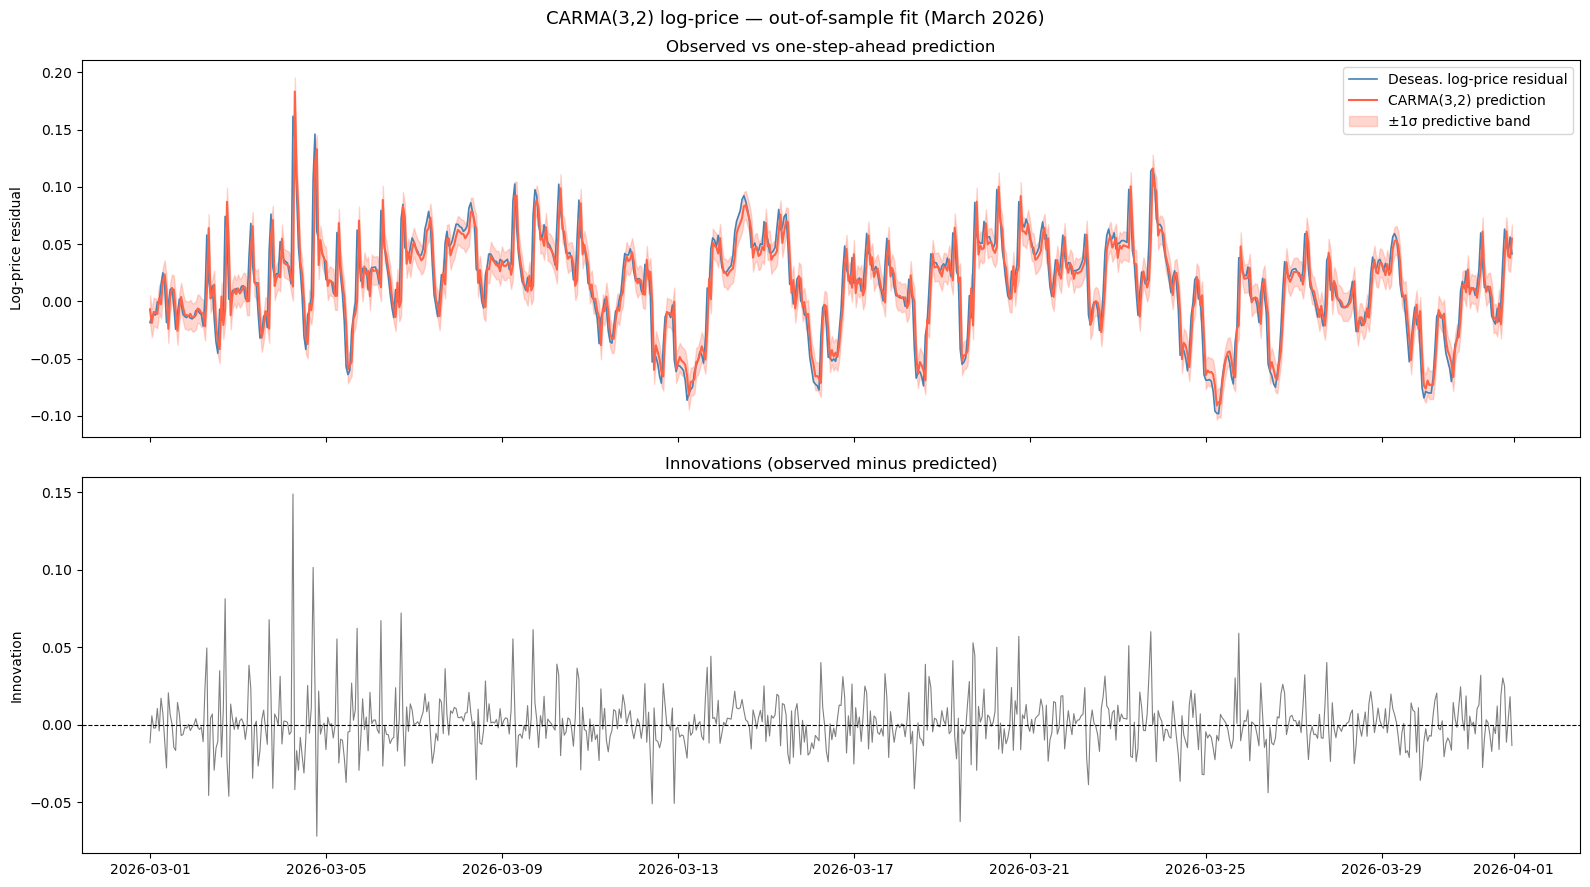

In [9]:
# Drop NaN rows, then warm-start from the last training state to the first valid 2026 observation.
_valid = ~np.isnan(price_2026_resid)
y_p26 = price_2026_resid[_valid].astype(float)
time_p26_idx = time_price_26[_valid]
t_p26 = hours_from_index(time_p26_idx)
err_p26 = np.full(len(y_p26), 1e-6)

_Ap = res_price["A"]
_Lp = res_price["L"]
dt_gap_p = float((time_p26_idx[0] - time_price[-1]) / pd.Timedelta(hours=1))
_F_gap_p, _Q_gap_p = discretize_linear_sde(_Ap, _Lp, dt=dt_gap_p)
x0_p = _F_gap_p @ res_price["x_filt"][-1]
P0_p = _F_gap_p @ res_price["P_filt"][-1] @ _F_gap_p.T + _Q_gap_p
P0_p = project_symmetric_psd(P0_p)

res_p26 = kalman_filter_carma32(
    t=t_p26, y=y_p26,
    a1=a1_p, a2=a2_p, a3=a3_p,
    b0=b0_p, b1=b1_p, b2=b2_p,
    sigma=sigma_p, yerr=err_p26,
    x0=x0_p, P0=P0_p,
)
y_hat_p26 = res_p26["y_pred"]
innov_p26 = res_p26["resid"]
z_p26 = res_p26["std_resid"]

n_params_p = 7
loglik_tr_p = float(res_price["loglik"])
loglik_oos_p = float(res_p26["loglik"])
n_tr_p = len(price_res)

metrics_p = {
    "Log-lik": {
        "train": loglik_tr_p,
        "OOS 2026": loglik_oos_p,
    },
    "Log-lik / obs": {
        "train": loglik_tr_p / n_tr_p,
        "OOS 2026": loglik_oos_p / len(y_p26),
    },
    "AIC": {
        "train": -2 * loglik_tr_p + 2 * n_params_p,
        "OOS 2026": -2 * loglik_oos_p + 2 * n_params_p,
    },
    "RMSE": {
        "train": float(np.sqrt(np.mean((price_res.to_numpy() - res_price["y_pred"]) ** 2))),
        "OOS 2026": float(np.sqrt(np.mean((y_p26 - y_hat_p26) ** 2))),
    },
    "MAE": {
        "train": float(np.mean(np.abs(price_res.to_numpy() - res_price["y_pred"]))),
        "OOS 2026": float(np.mean(np.abs(y_p26 - y_hat_p26))),
    },
    "Innovation mean": {
        "train": float(res_price["resid"].mean()),
        "OOS 2026": float(innov_p26.mean()),
    },
    "Innovation std": {
        "train": float(res_price["resid"].std()),
        "OOS 2026": float(innov_p26.std()),
    },
    "Std innov mean": {
        "train": float(res_price["std_resid"].mean()),
        "OOS 2026": float(z_p26.mean()),
    },
    "Std innov std": {
        "train": float(res_price["std_resid"].std()),
        "OOS 2026": float(z_p26.std()),
    },
}

_diag_p = pd.DataFrame(metrics_p).T
_diag_p = add_abs_ratio(_diag_p)
print("=== CARMA(3,2) log-price — in-sample vs OOS diagnostics ===")
print(_diag_p.round(5).to_string())

mask_mar_p = (time_p26_idx >= pd.Timestamp("2026-03-01", tz="UTC")) & (
    time_p26_idx < pd.Timestamp("2026-04-01", tz="UTC")
)

t_mar_p = time_p26_idx[mask_mar_p]
y_mar_p = y_p26[mask_mar_p]
yhat_mar_p = y_hat_p26[mask_mar_p]
inn_mar_p = innov_p26[mask_mar_p]
_std_mar_p = np.sqrt(res_p26["S"][mask_mar_p])

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle("CARMA(3,2) log-price — out-of-sample fit (March 2026)", fontsize=13)

axes[0].plot(t_mar_p, y_mar_p, linewidth=1.2, label="Deseas. log-price residual", color="steelblue")
axes[0].plot(t_mar_p, yhat_mar_p, linewidth=1.5, label="CARMA(3,2) prediction", color="tomato")
axes[0].fill_between(
    t_mar_p, yhat_mar_p - _std_mar_p, yhat_mar_p + _std_mar_p,
    alpha=0.25, color="tomato", label="±1σ predictive band",
)
axes[0].legend()
axes[0].set_ylabel("Log-price residual")
axes[0].set_title("Observed vs one-step-ahead prediction")

axes[1].plot(t_mar_p, inn_mar_p, linewidth=0.8, color="grey")
axes[1].axhline(0, linestyle="--", color="k", linewidth=0.8)
axes[1].set_ylabel("Innovation")
axes[1].set_title("Innovations (observed minus predicted)")

plt.tight_layout()
plt.show()


### Monthly out-of-sample RMSE

Monthly RMSE on the 2026 out-of-sample period is compared with the mean monthly RMSE on the in-sample period.


     series  in_sample_mean_monthly_RMSE  OOS_2026_mean_monthly_RMSE  OOS_to_in_sample_ratio
temperature                      0.59622                     0.50573                 0.84823
      price                      0.01166                     0.01373                 1.17761


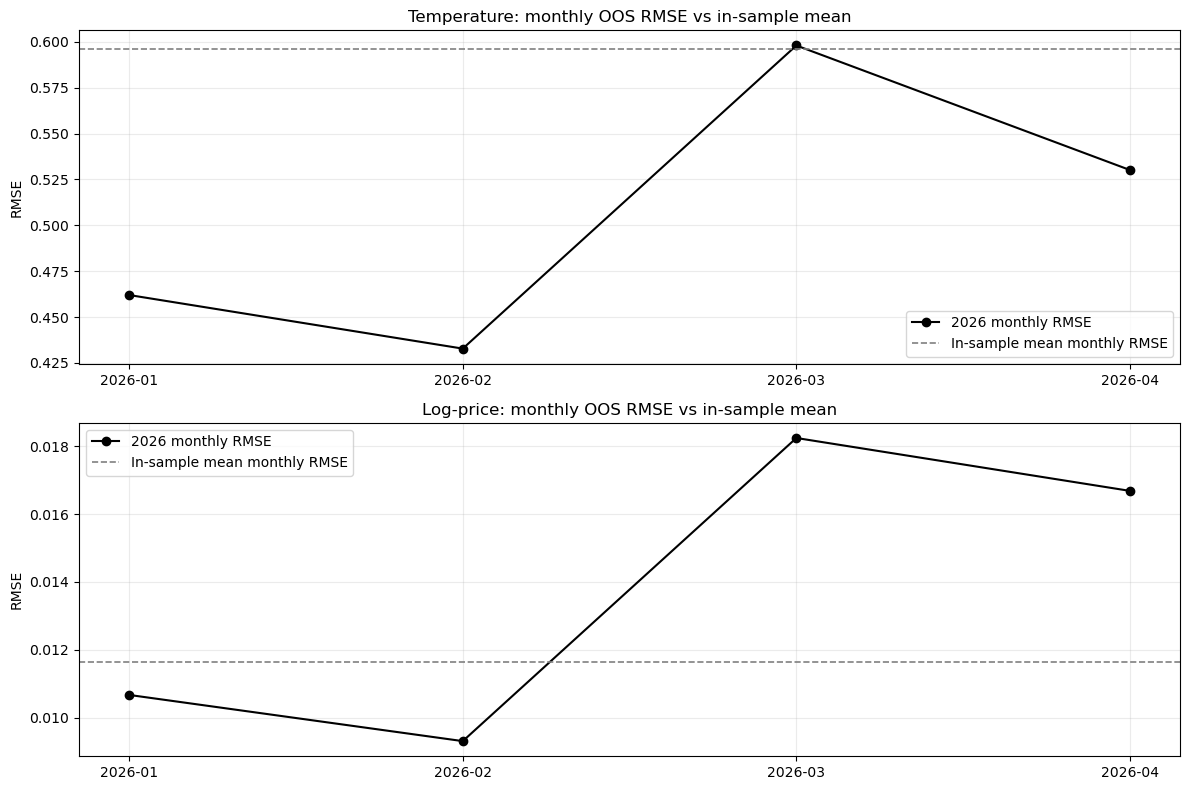

In [10]:
def monthly_rmse(index, y_true, y_pred):
    idx = pd.DatetimeIndex(pd.to_datetime(index, utc=True))
    idx = idx.tz_convert(None)
    df = pd.DataFrame(
        {
            "y_true": np.asarray(y_true, dtype=float),
            "y_pred": np.asarray(y_pred, dtype=float),
        },
        index=idx,
    ).dropna()
    sq_err = (df["y_true"] - df["y_pred"]) ** 2
    return sq_err.groupby(sq_err.index.to_period("M")).mean().pow(0.5)


temp_train_monthly_rmse = monthly_rmse(time_temp, temp_res.to_numpy(), res_temp["y_pred"])
temp_oos_monthly_rmse = monthly_rmse(time_2026, y_2026, y_hat_2026)
price_train_monthly_rmse = monthly_rmse(time_price, price_res.to_numpy(), res_price["y_pred"])
price_oos_monthly_rmse = monthly_rmse(time_p26_idx, y_p26, y_hat_p26)

monthly_rmse_summary = pd.DataFrame(
    {
        "series": ["temperature", "price"],
        "in_sample_mean_monthly_RMSE": [
            temp_train_monthly_rmse.mean(),
            price_train_monthly_rmse.mean(),
        ],
        "OOS_2026_mean_monthly_RMSE": [
            temp_oos_monthly_rmse.mean(),
            price_oos_monthly_rmse.mean(),
        ],
    }
)
monthly_rmse_summary["OOS_to_in_sample_ratio"] = (
    monthly_rmse_summary["OOS_2026_mean_monthly_RMSE"]
    / monthly_rmse_summary["in_sample_mean_monthly_RMSE"]
)

print(monthly_rmse_summary.round(5).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(
    temp_oos_monthly_rmse.index.astype(str),
    temp_oos_monthly_rmse.values,
    marker="o",
    linewidth=1.5,
    color="black",
    label="2026 monthly RMSE",
)
axes[0].axhline(
    temp_train_monthly_rmse.mean(),
    linestyle="--",
    linewidth=1.2,
    color="grey",
    label="In-sample mean monthly RMSE",
)
axes[0].set_title("Temperature: monthly OOS RMSE vs in-sample mean")
axes[0].set_ylabel("RMSE")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    price_oos_monthly_rmse.index.astype(str),
    price_oos_monthly_rmse.values,
    marker="o",
    linewidth=1.5,
    color="black",
    label="2026 monthly RMSE",
)
axes[1].axhline(
    price_train_monthly_rmse.mean(),
    linestyle="--",
    linewidth=1.2,
    color="grey",
    label="In-sample mean monthly RMSE",
)
axes[1].set_title("Log-price: monthly OOS RMSE vs in-sample mean")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


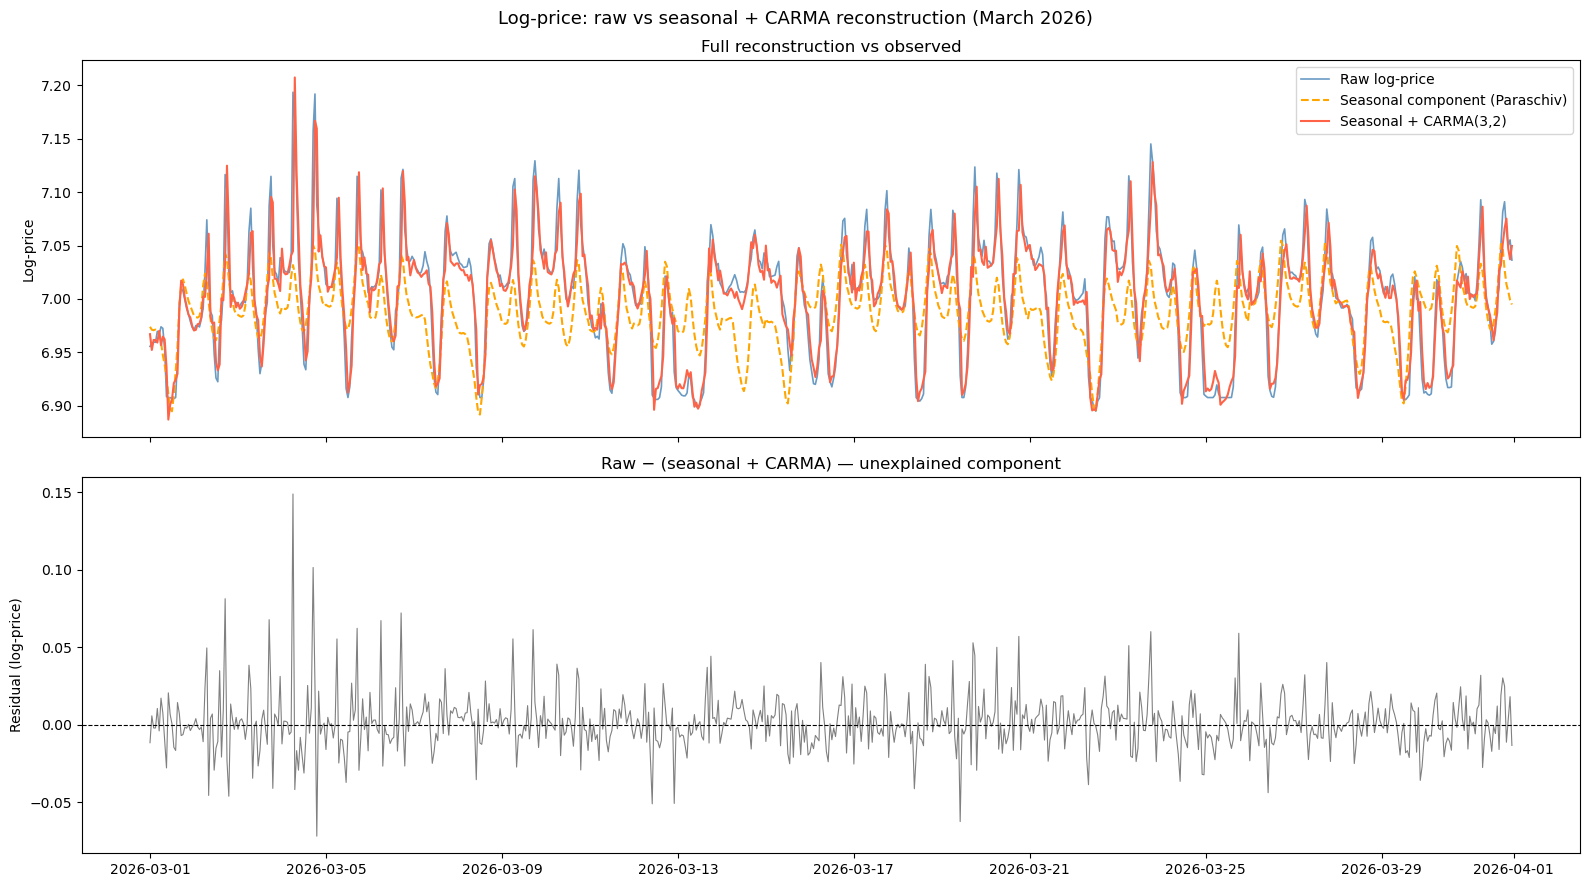

RMSE seasonal only    : 0.04402
RMSE seasonal + CARMA : 0.01824
CARMA improvement     : 58.6%


In [11]:
# Reconstruction: raw log-price vs seasonal + CARMA fit (March 2026)
_seas_mar_p  = price_2026_seas[_valid][mask_mar_p]
_raw_mar_p   = price_2026_raw[_valid][mask_mar_p]
_recon_mar_p = _seas_mar_p + yhat_mar_p

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle("Log-price: raw vs seasonal + CARMA reconstruction (March 2026)", fontsize=13)

axes[0].plot(t_mar_p, _raw_mar_p,   linewidth=1.2, alpha=0.8,
             label="Raw log-price",                  color="steelblue")
axes[0].plot(t_mar_p, _seas_mar_p,  linewidth=1.5, linestyle="--",
             label="Seasonal component (Paraschiv)",  color="orange")
axes[0].plot(t_mar_p, _recon_mar_p, linewidth=1.5,
             label="Seasonal + CARMA(3,2)",           color="tomato")
axes[0].set_ylabel("Log-price")
axes[0].set_title("Full reconstruction vs observed")
axes[0].legend()

axes[1].plot(t_mar_p, _raw_mar_p - _recon_mar_p, linewidth=0.8, color="grey")
axes[1].axhline(0, linestyle="--", color="k", linewidth=0.8)
axes[1].set_ylabel("Residual (log-price)")
axes[1].set_title("Raw \u2212 (seasonal + CARMA) \u2014 unexplained component")

plt.tight_layout()
plt.show()

_rmse_recon_p = float(np.sqrt(np.mean((_raw_mar_p - _recon_mar_p) ** 2)))
_rmse_seas_p  = float(np.sqrt(np.mean((_raw_mar_p - _seas_mar_p)  ** 2)))
print(f"RMSE seasonal only    : {_rmse_seas_p:.5f}")
print(f"RMSE seasonal + CARMA : {_rmse_recon_p:.5f}")
print(f"CARMA improvement     : {(1 - _rmse_recon_p/_rmse_seas_p)*100:.1f}%")
